# Dynamic programming (DP)



Idea of breaking down a larger problems recursively into subproblems

Programming: optimising a “program”, i.e. a policy

Breaking into subproblems:
- Solve the subproblems
- Combine solutions to subproblems

Dynamic Programming is a very general solution method for problems which have two properties:
- Optimal substructure
    Optimal solution can be decomposed into subproblems
- Overlapping subproblems
    Subproblems recur many times
    Solutions can be cached and reused

Markov decision processes satisfy both properties
- Bellman equation gives recursive decomposition
- Value function stores and reuses solutions


## Planning by DP

Dynamic programming assumes full knowledge of the MDP (Requires a perfect model of env.)
It is used for planning in an MDP. 

Planning = simulate future trajectories using a model of env to improve policy/value estimate. Instead of learning purely from real experience, the agent "thinks ahead" by querying an internal model

Full knowledge: 
- transitions: next state
- rewards



Nb: DP used to solve other problems like sequence alignement (string), graph algo (shortest path), graphical model (viterbi),...


## Iterative Policy evaluation (Prediction)

Problem: evaluate a given policy $\pi$
Solution: iterative application of Bellman expectation

v1 -> v2 -> v3 -> ... -> $v_\pi$


Use synchronous backup:
- at each iteration k
- for all states (synchronous)
    - update $v_{k+1}(s)$ from $v_k(s')$
    - s' is successor state




How to compute action-value function

From previous section we know:

<img src="./imgs/image-66.png" width="500px" /><div/>


State-value function is the average of all the available action-values, weighted by how likely we are to choose them under our current policy:

We apply the Bellmann equation as an update rule, and compute for each state



### Example with simple grid

<img src="./imgs/image-76.png" width="500px" /><div/>

- Undiscounted episodic MDP (γ = 1)
- Nonterminal states 1,...,14
- One terminal state (shown twice as shaded squares)
- Actions leading out of the grid leave state unchanged
- Reward is −1 until the terminal state is reached
- Agent follows uniform random policy (1/4 (actions)=0.25)
    


k=0: Value initialized to 0
k=1: value = reward (synchronous -> we evaluate all states)
k=2: 
    -2 (immediate reward + prev value)
    -   

<img src="./imgs/image-77.png" width="500px" /><div/>

<img src="./imgs/image-78.png" width="500px" /><div/>

### Iterative Policy Evaluation, for estimating $V \approx v_\pi$

Input $\pi$, the policy to be evaluated

Algorithm parameter: a small threshold $\theta > 0$ determining accuracy of estimation

Initialize $V(s)$ arbitrarily, for $s \in \mathcal{S}$, and $V(\textit{terminal})$ to $0$

> Loop:
>> $\Delta \leftarrow 0$

>> Loop for each $s \in \mathcal{S}$:
>>> $v \leftarrow V(s)$

>>> $V(s) \leftarrow \sum_a \pi(a|s) \sum_{s',r} p(s',r|s,a)\big[r + \gamma V(s')\big]$

>>> $\Delta \leftarrow \max(\Delta, |v - V(s)|)$

> until $\Delta < \theta$



**In iterative policy evaluation**, we evaluate any given policy (like uniform)

#### Code implementation

Bellman equation to update V: 

$V(s)\leftarrow r(s)+\gamma\sum_{s'}P(s'|s)V(s')$

In [1]:
import numpy as np

# ---------- MDP definition (dicts) ----------
states = ["Class1", "Class2", "Class3", "Facebook", "Pub", "Pass", "Sleep"]
terminal_states = ["Sleep"]  # , "Pass"]
state_names = ["C1", "C2", "C3", "FB", "Sleep"]

S = list(state_names)  # ["C1", "C2", "C3", "FB", "Sleep"]
terminal_states_mdp = {"Sleep"}

A = {
    "C1": ["study", "facebook"],
    "C2": ["study", "sleep"],
    "C3": ["study", "pub"],
    "FB": ["quit", "facebook"],
    "Sleep": [],
}

# Transition model: P[(s,a)] = [(prob, s_next), ...]
P_sa = {
    ("C1", "study"): [(1.0, "C2")],
    ("C1", "facebook"): [(1.0, "FB")],
    ("C2", "study"): [(1.0, "C3")],
    ("C2", "sleep"): [(1.0, "Sleep")],
    # Study in C3 gives +10 then day ends
    ("C3", "study"): [(1.0, "Sleep")],
    # Pub in C3 transitions back to class states
    ("C3", "pub"): [(0.2, "C1"), (0.4, "C2"), (0.4, "C3")],
    ("FB", "quit"): [(1.0, "C1")],
    ("FB", "facebook"): [(1.0, "FB")],
}

# Reward model: R[(s,a)] = immediate reward for taking action a in s
R_sa = {
    ("C1", "study"): -2.0,
    ("C1", "facebook"): -1.0,
    ("C2", "study"): -2.0,
    ("C2", "sleep"): 0.0,
    ("C3", "study"): 10.0,
    ("C3", "pub"): 1.0,
    ("FB", "quit"): 0.0,
    ("FB", "facebook"): -1.0,
}

# not used
r = {
    "Class1": -2.0,
    "Class2": -2.0,
    "Class3": -2.0,
    "Facebook": -1.0,
    "Pub": 1.0,
    "Sleep": 0.0,
    "Pass": 10.0,
}


def actions(s):
    return A[s]


def transitions_sa(s, a):
    return P_sa[(s, a)]


def reward_sa(s, a):
    return float(R_sa[(s, a)])


In [2]:
# Iterative policy evaluation on the student MDP using the uniform random policy

V = {s: 0.0 for s in S}
gamma = 0.9
theta = 1e-6


def iterative_policy_evaluation(V, S, terminal_states_mdp, gamma, theta):
    iterations = 0
    while True:
        delta = 0.0

        for s in S:
            if s in terminal_states_mdp:
                continue

            v = V[s]

            # V(s) <- sum_a pi(a|s) * sum_{s',r} p(s',r|s,a) * [r + gamma * V(s')]
            new_v = 0.0
            # ******
            # Here we evaluate a uniform random policy: pi(a|s) = 1/|A(s)| for all a in A(s)
            prob_a = 1.0 / len(actions(s))
            for a in actions(s):
                q_sa = 0.0
                for p, s_next in transitions_sa(s, a):
                    q_sa += p * (reward_sa(s, a) + gamma * V[s_next])
                new_v += prob_a * q_sa

            V[s] = new_v
            delta = max(delta, abs(v - V[s]))

        iterations += 1

        if delta < theta:
            break

    return V, iterations


V, iterations = iterative_policy_evaluation(V, S, terminal_states_mdp, gamma, theta)


print(f"Converged in {iterations} iterations\n")
print("State values under uniform random policy:")
for s in S:
    print(f"  {s:>5}: {V[s]: .6f}")

Converged in 33 iterations

State values under uniform random policy:
     C1: -1.484479
     C2:  2.158158
     C3:  7.018128
     FB: -2.123665
  Sleep:  0.000000


## Policy iteration

### Policy improvement

From predicting value (estimation) -> move to control problem

Given a policy π
- Evaluate the policy π
    $$v_π(s) = E [R_{t+1} + γR_{t+2} +...|S_t = s]$$
- Improve the policy by acting greedily with respect to $v_π$
$$π' = greedy(v_π)$$

Always converge to $\pi*$ , optimal policy

**In policy evalution example (above) we used a uniform policy not a greedy one.**

<img src="./imgs/image-79.png" width="600px" /><div/>



- Consider a deterministic policy, $a = \pi(s)$
- We can *improve* the policy by acting greedily

$$\pi'(s) = \argmax_{a \in \mathcal{A}} q_\pi(s, a)$$

> Instead of following the current policy (like uniform random), pick the action with the highest action-value at every state.

- This improves the value from any state $s$ over one step,

$$q_\pi(s, \pi'(s)) = \max_{a \in \mathcal{A}} q_\pi(s, a) \geq q_\pi(s, \pi(s)) = v_\pi(s)$$

> The greedy action is at least as good as whatever the old policy was doing — so $\pi'$ is no worse than $\pi$ at any state.

- It therefore improves the value function, $v_{\pi'}(s) \geq v_\pi(s)$

$$
\begin{aligned}
v_\pi(s) &\leq q_\pi(s, \pi'(s)) = \mathbb{E}_{\pi'}\left[R_{t+1} + \gamma v_\pi(S_{t+1}) \mid S_t = s\right] \\
&\leq \mathbb{E}_{\pi'}\left[R_{t+1} + \gamma q_\pi(S_{t+1}, \pi'(S_{t+1})) \mid S_t = s\right] \\
&\leq \mathbb{E}_{\pi'}\left[R_{t+1} + \gamma R_{t+2} + \gamma^2 q_\pi(S_{t+2}, \pi'(S_{t+2})) \mid S_t = s\right] \\
&\leq \mathbb{E}_{\pi'}\left[R_{t+1} + \gamma R_{t+2} + \ldots \mid S_t = s\right] = v_{\pi'}(s)
\end{aligned}
$$

> Each line substitutes $v_\pi$ with $q_\pi$ and applies the greedy improvement one step further into the future. Unrolling this to infinity shows the full return under $\pi'$ is at least as large as $v_\pi(s)$ — so the new policy is globally at least as good.

#### Policy Improvement — Convergence

- If improvements stop,

$$q_\pi(s, \pi'(s)) = \max_{a \in \mathcal{A}} q_\pi(s, a) = q_\pi(s, \pi(s)) = v_\pi(s)$$

> The greedy policy $\pi'$ picks the same actions as $\pi$. No further improvement is possible.

- Then the Bellman optimality equation has been satisfied

$$v_\pi(s) = \max_{a \in \mathcal{A}} q_\pi(s, a)$$

> This is exactly the definition of the optimal value function — the value equals the best possible action-value at every state.

- Therefore $v_\pi(s) = v_*(s)$ for all $s \in \mathcal{S}$
- so $\pi$ is an optimal policy

> When greedy improvement changes nothing, we've found $v_*$ and the policy is optimal.

### Modified Policy Iteration

- Does policy evaluation need to converge to $v_\pi$?
- Or should we introduce a stopping condition
  - e.g. $\epsilon$-convergence of value function
- Or simply stop after $k$ iterations of iterative policy evaluation?
- For example, in the small gridworld $k = 3$ was sufficient to achieve optimal policy
- Why not update policy every iteration? i.e. stop after $k = 1$
  - This is equivalent to *value iteration* (next section)

> Full convergence of policy evaluation is expensive and unnecessary. Stopping early (after $k$ steps, or once changes are small) still yields correct policy improvement. The extreme case — improve after every single sweep — is value iteration.

#### Generalized policy iteration

Policy evaluation: Estimate vπ

-> Any policy evaluation algorithm

Policy improvement: Generate π′≥π

-> Any policy improvement algorithm

#### Policy iteration algorithm

chain these improvement steps with policy evaluation


<img src="./imgs/image-72.png" width="700px" /><div/>

Each of the resulting policies are monotonically improving, and — since finite MDPs only have finite states — this process must converge to the optimal policy eventually!

So first algorithm for solving an RL problem — called policy iteration


<img src="./imgs/image-73.png" width="700px" /><div/>


In [5]:
def policy_iteration(S, terminal_states_mdp, gamma, theta):
    """
    Policy iteration algorithm.

    Returns:
        V: optimal state-value function
        policy: optimal policy (dict mapping state -> action)
        iterations: number of policy iterations
    """
    # Initialize policy arbitrarily (choose first available action for each state)
    policy = {}
    for s in S:
        if s not in terminal_states_mdp:
            policy[s] = actions(s)[0]

    print("Initial policy:")
    print(policy)

    iterations = 0

    while True:
        iterations += 1

        # Policy Evaluation: compute V under current deterministic policy
        V = {s: 0.0 for s in S}
        while True:
            delta = 0.0
            for s in S:
                if s in terminal_states_mdp:
                    continue
                v = V[s]
                # act greedily according to current policy, we do not iterate over all actions here,
                # only the one specified by the current policy
                a = policy[s]
                new_v = 0.0
                for p, s_next in transitions_sa(s, a):
                    new_v += p * (reward_sa(s, a) + gamma * V[s_next])
                V[s] = new_v
                delta = max(delta, abs(v - V[s]))
            if delta < theta:
                break

        # Policy Improvement: act greedily with respect to V
        policy_stable = True

        for s in S:
            if s in terminal_states_mdp:
                continue

            old_action = policy[s]

            # Find best action by computing q(s,a) for all actions
            best_action = None
            best_value = float("-inf")

            for a in actions(s):
                q_sa = 0.0
                for p, s_next in transitions_sa(s, a):
                    q_sa += p * (reward_sa(s, a) + gamma * V[s_next])

                if q_sa > best_value:
                    best_value = q_sa
                    best_action = a

            policy[s] = best_action

            if old_action != best_action:
                policy_stable = False

        # If policy is stable, we've found the optimal policy
        if policy_stable:
            break

    return V, policy, iterations


V, policy, iterations = policy_iteration(S, terminal_states_mdp, gamma, theta)

Initial policy:
{'C1': 'study', 'C2': 'study', 'C3': 'study', 'FB': 'quit'}


Policy iteration converged in 1 iteration(s)

State       V*(s)      pi*(s)
-----------------------------
C1         4.3000       study
C2         7.0000       study
C3        10.0000       study
FB         3.8700        quit
Sleep      0.0000    TERMINAL


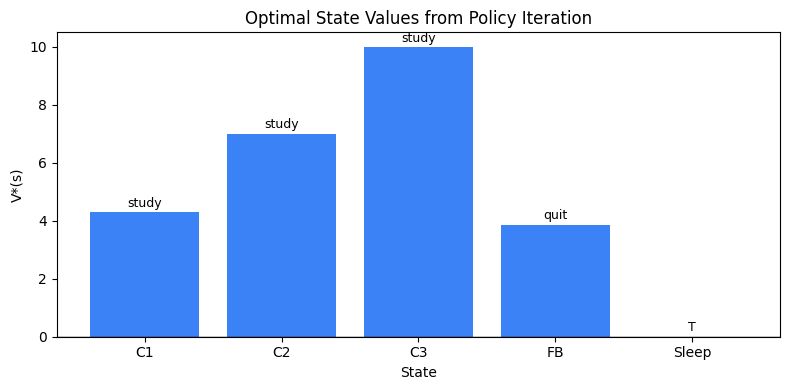

In [4]:
print(f"Policy iteration converged in {iterations} iteration(s)\n")

# Text table
state_w = max(len(s) for s in S)
header = f"{'State':<{state_w}}  {'V*(s)':>10}  {'pi*(s)':>10}"
print(header)
print("-" * len(header))
for s in S:
    action = "TERMINAL" if s in terminal_states_mdp else policy[s]
    print(f"{s:<{state_w}}  {V[s]:>10.4f}  {action:>10}")

# Simple value plot
import matplotlib.pyplot as plt

values = [V[s] for s in S]
colors = ["#9ca3af" if s in terminal_states_mdp else "#3b82f6" for s in S]

plt.figure(figsize=(8, 4))
bars = plt.bar(S, values, color=colors)
plt.axhline(0.0, color="black", linewidth=1)
plt.title("Optimal State Values from Policy Iteration")
plt.ylabel("V*(s)")
plt.xlabel("State")

for bar, s in zip(bars, S):
    label = "T" if s in terminal_states_mdp else policy[s]
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y + (0.08 if y >= 0 else -0.2),
        label,
        ha="center",
        va="bottom" if y >= 0 else "top",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


- Iterative policy evaluation computes $v_\pi$  for the uniform random policy (equal probability over all actions)
- Policy iteration computes $v_{\pi^*}$ for the optimal deterministic policy (greedily improved). The optimal policy will generally have higher values since the random policy wastes time on bad actions (e.g., going to Facebook instead of studying).

## Value Iteration

### Principle of Optimality

Any optimal policy can be subdivided into two components:
- An optimal first action $A_*$
- Followed by an optimal policy from successor state $S'$

**Theorem (Principle of Optimality)**

A policy $\pi(a|s)$ achieves the optimal value from state $s$, $v_\pi(s) = v_*(s)$, if and only if:

- For any state $s'$ reachable from $s$
- $\pi$ achieves the optimal value from state $s'$, $v_\pi(s') = v_*(s')$

> If a policy is optimal globally, it must also be optimal from every state it can reach. You can't have a globally optimal policy that makes suboptimal decisions in some future situation — that future suboptimality would propagate back and reduce the current value.

### Deterministic Value Iteration

- If we know the solution to subproblems $v_*(s')$
- Then solution $v_*(s)$ can be found by one-step lookahead

$$v_*(s) \leftarrow \max_{a \in \mathcal{A}} \mathcal{R}_s^a + \gamma \sum_{s' \in \mathcal{S}} \mathcal{P}_{ss'}^a v_*(s')$$

> Pick the action that maximises immediate reward plus the (already known) optimal value of the next state.

- The idea of value iteration is to apply these updates iteratively
- Intuition: start with final rewards and work backwards
- Still works with loopy, stochastic MDPs

> **Unlike policy iteration, there is no explicit policy**. We just keep applying the Bellman optimality update to every state until values stop changing — the optimal policy is implicit in whichever action achieves the max.

### Value Iteration

- Problem: find optimal policy $\pi$
- Solution: iterative application of Bellman optimality backup
- $v_1 \rightarrow v_2 \rightarrow \ldots \rightarrow v_*$
- Using synchronous backups
  - At each iteration $k+1$
  - For all states $s \in \mathcal{S}$
  - Update $v_{k+1}(s)$ from $v_k(s')$

- Convergence to $v_*$ will be proven later
- Unlike policy iteration, there is no explicit policy
- Intermediate value functions may not correspond to any policy


> Value iteration sweeps through all states and applies the Bellman optimality update using the *current* value estimates. No policy is maintained — just the value table. Each sweep gets closer to $v_*$, and the optimal policy can be extracted at the end by acting greedily. Intermediate value functions are just numerical approximations, not necessarily consistent with any real policy.


<img src="./imgs/image-80.png" width="500px" />

Optimal value function V*:
     C1:  4.300000
     C2:  7.000000
     C3:  10.000000
     FB:  3.870000
  Sleep:  0.000000

Greedy optimal policy π*:
     C1 -> study
     C2 -> study
     C3 -> study
     FB -> quit
  Sleep -> TERMINAL


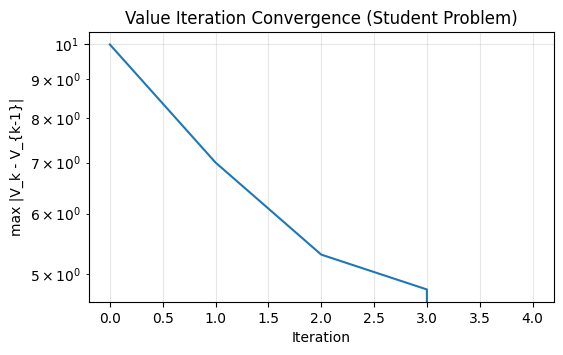

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def value_iteration_dict(
    S, terminal_states_mdp, gamma=0.9, theta=1e-8, max_iters=10_000
):
    """
    Value iteration for the student MDP defined with dicts:
    - actions(s)
    - transitions_sa(s, a) -> list[(p, s_next)]
    - reward_sa(s, a)
    """
    V = {s: 0.0 for s in S}
    deltas = []

    for _ in range(max_iters):
        delta = 0.0
        V_new = {}

        for s in S:
            if s in terminal_states_mdp:
                V_new[s] = 0.0
                continue

            best_q = float("-inf")
            for a in actions(s):
                q_sa = 0.0
                for p, s_next in transitions_sa(s, a):
                    q_sa += p * (reward_sa(s, a) + gamma * V[s_next])
                if q_sa > best_q:
                    best_q = q_sa

            V_new[s] = best_q
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        deltas.append(delta)
        if delta < theta:
            break

    # Greedy policy extraction
    policy = {}
    for s in S:
        if s in terminal_states_mdp:
            continue

        best_a = None
        best_q = float("-inf")
        for a in actions(s):
            q_sa = 0.0
            for p, s_next in transitions_sa(s, a):
                q_sa += p * (reward_sa(s, a) + gamma * V[s_next])
            if q_sa > best_q:
                best_q = q_sa
                best_a = a
        policy[s] = best_a

    return V, policy, deltas


# Run
V_star, pi_star, deltas = value_iteration_dict(
    S, terminal_states_mdp, gamma=gamma, theta=theta
)

print("Optimal value function V*:")
for s in S:
    print(f"  {s:>5}: {V_star[s]: .6f}")

print("\nGreedy optimal policy π*:")
for s in S:
    if s in terminal_states_mdp:
        print(f"  {s:>5} -> TERMINAL")
    else:
        print(f"  {s:>5} -> {pi_star[s]}")

# Convergence plot
plt.figure(figsize=(6, 3.5))
plt.plot(deltas)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("max |V_k - V_{k-1}|")
plt.title("Value Iteration Convergence (Student Problem)")
plt.grid(True, alpha=0.3)
plt.show()

## Summary of DP algorithms

### Synchronous Dynamic Programming Algorithms

| Problem | Bellman Equation | Algorithm |
|---|---|---|
| Prediction | Bellman Expectation Equation | Iterative Policy Evaluation |
| Control | Bellman Expectation Equation + Greedy Policy Improvement | Policy Iteration |
| Control | Bellman Optimality Equation | Value Iteration |

- Algorithms are based on state-value function $v_\pi(s)$ or $v_*(s)$
- Complexity $O(mn^2)$ per iteration, for $m$ actions and $n$ states
- Could also apply to action-value function $q_\pi(s, a)$ or $q_*(s, a)$
- Complexity $O(m^2n^2)$ per iteration


> **Prediction vs Control:** Prediction asks "how good is this policy?" — it evaluates a *fixed* policy. Control asks "what is the *best* policy?" — it optimizes.
>
> **Iterative Policy Evaluation** repeatedly applies the Bellman Expectation Equation until $v_\pi(s)$ converges — i.e. until the value of every state stabilizes under the current policy.
>
> **Policy Iteration** alternates between evaluation (compute $v_\pi$) and improvement (act greedily w.r.t. $v_\pi$). Converges to $\pi_*$.
>
> **Value Iteration** skips full policy evaluation and applies the Bellman *Optimality* Equation directly at each step — effectively doing one-step lookahead and taking the max over actions.
>
> **Complexity $O(mn^2)$:** For each of $n$ states, computing $v(s)$ requires summing over $n$ successor states for each of $m$ actions → $m \cdot n$ work per state → $mn^2$ total. The $O(m^2n^2)$ figure applies to action-value functions $q(s,a)$, where both the $m$ actions and $n$ next-states must be iterated for each of the $mn$ state-action pairs.

## Asynchronous dynamic programming


- DP methods described so far used *synchronous* backups
- i.e. all states are backed up in parallel
- *Asynchronous DP* backs up states individually, in any order
- For each selected state, apply the appropriate backup
- Can significantly reduce computation
- Guaranteed to converge if all states continue to be selected

> **Synchronous vs Asynchronous:** Synchronous DP sweeps through *all* states at every iteration — expensive if the state space is large. Asynchronous DP updates states one at a time, in any order, as often as needed.
>
> **Why it helps:** You can focus updates on states that matter most (e.g. states the agent actually visits), skipping rarely-relevant states. This makes DP practical for large MDPs.
>
> **Convergence guarantee:** The only requirement is that no state gets permanently ignored — every state must be selected infinitely often in the limit. The order and frequency of updates otherwise don't matter.


### Three Ideas for Asynchronous Dynamic Programming

Three simple ideas for asynchronous dynamic programming:

- *In-place dynamic programming*
- *Prioritised sweeping*
- *Real-time dynamic programming*

> **In-place DP:** Standard synchronous DP keeps two copies of the value table — old and new. In-place DP uses only one table and overwrites values immediately. Updates later in the sweep already benefit from fresher estimates, often converging faster.
>
> **Prioritised sweeping:** Not all states are equally worth updating. Prioritise states where the Bellman error is largest — i.e. where the current value estimate is most "wrong". Use a priority queue to always update the most impactful state next.
>
> **Real-time DP:** Only update states that the agent actually visits during interaction. The agent's experience drives which states get backed up — irrelevant parts of the state space are never touched.

#### In-Place Dynamic Programming

- Synchronous value iteration stores two copies of value function

    for all $s$ in $\mathcal{S}$

$$v_{new}(s) \leftarrow \max_{a \in \mathcal{A}} \left( \mathcal{R}_s^a + \gamma \sum_{s' \in \mathcal{S}} \mathcal{P}_{ss'}^a v_{old}(s') \right)$$

$$v_{old} \leftarrow v_{new}$$

- In-place value iteration only stores one copy of value function

    for all $s$ in $\mathcal{S}$

$$v(s) \leftarrow \max_{a \in \mathcal{A}} \left( \mathcal{R}_s^a + \gamma \sum_{s' \in \mathcal{S}} \mathcal{P}_{ss'}^a v(s') \right)$$

> **Synchronous:** Two tables — $v_{old}$ and $v_{new}$. Every state is updated using only values from the *previous* sweep, then the old table is replaced. Clean but memory-costly.
>
> **In-place:** One table — $v$. When updating state $s$, any $v(s')$ already updated earlier in the same sweep is used immediately. No second table needed.
>
> **Why in-place is often faster:** Some states benefit right away from fresher neighbour values, propagating information more quickly through the state space. Convergence is still guaranteed.

#### Prioritised Sweeping

- Use magnitude of Bellman error to guide state selection, e.g.

$$\left| \max_{a \in \mathcal{A}} \left( \mathcal{R}_s^a + \gamma \sum_{s' \in \mathcal{S}} \mathcal{P}_{ss'}^a v(s') \right) - v(s) \right|$$

- Backup the state with the largest remaining Bellman error
- Update Bellman error of affected states after each backup
- Requires knowledge of reverse dynamics (predecessor states)
- Can be implemented efficiently by maintaining a priority queue

> **Bellman error:** The gap between the current value estimate $v(s)$ and what the Bellman equation says it *should* be. A large error means the state's value is stale and most in need of an update.
>
> **The idea:** Instead of sweeping all states blindly, always pick the state where an update will make the biggest difference. This focuses computation where it matters.
>
> **Why predecessor states?** After updating $v(s)$, the Bellman error of states that *lead to* $s$ may change — they now have a more accurate successor value. So their errors must be recomputed and re-inserted into the queue.
>
> **Priority queue:** Keeps states sorted by Bellman error magnitude. Pop the highest-error state, update it, push affected predecessors back in. Efficient and straightforward to implement.

#### Real-Time Dynamic Programming

- Idea: only update states that are relevant to agent
- Use agent's experience to guide the selection of states
- After each time-step $S_t, A_t, R_{t+1}$
- Backup the state $S_t$

$$v(S_t) \leftarrow \max_{a \in \mathcal{A}} \left( \mathcal{R}_{S_t}^a + \gamma \sum_{s' \in \mathcal{S}} \mathcal{P}_{S_t s'}^a v(s') \right)$$

> **Core idea:** Don't waste computation on states the agent never visits. Only update the state the agent is currently in — $S_t$ — after each real interaction step.
>
> **Experience-driven:** The agent's trajectory through the environment naturally determines which states get updated. Frequently visited states get updated often; irrelevant states never touched.
>
> **The update:** Standard value iteration backup, but applied only to $S_t$. Uses the current value estimates for all successor states $s'$.
>
> **Contrast with prioritised sweeping:** RTDP uses *actual* agent experience to select states; prioritised sweeping uses Bellman error magnitude. RTDP requires no priority queue and no knowledge of predecessor states.

In-Place Value Iteration
Converged in 4 iterations

     C1:  V =  4.300000   π = study
     C2:  V =  7.000000   π = study
     C3:  V =  10.000000   π = study
     FB:  V =  3.870000   π = quit
  Sleep:  V =  0.000000   π = TERMINAL


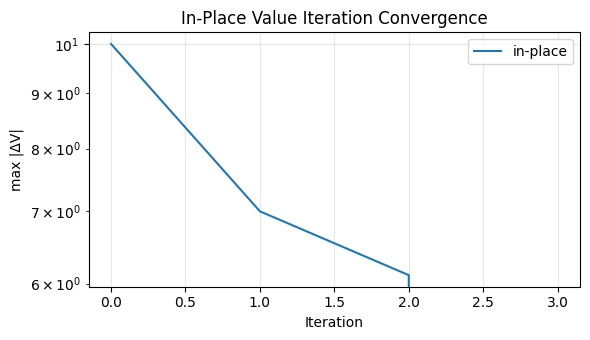

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── In-Place Value Iteration on the Student MDP ──
# Single value table, updated immediately (no V_old / V_new split)


def inplace_value_iteration(
    S, terminal_states_mdp, gamma=0.9, theta=1e-8, max_iters=10_000
):
    V = {s: 0.0 for s in S}
    deltas = []

    for _ in range(max_iters):
        delta = 0.0
        for s in S:
            if s in terminal_states_mdp:
                continue
            v_old = V[s]
            best_q = float("-inf")
            for a in actions(s):
                q_sa = sum(
                    p * (reward_sa(s, a) + gamma * V[s_next])
                    for p, s_next in transitions_sa(s, a)
                )
                best_q = max(best_q, q_sa)
            V[s] = best_q  # overwrite immediately
            delta = max(delta, abs(V[s] - v_old))
        deltas.append(delta)
        if delta < theta:
            break

    # Extract greedy policy
    policy = {}
    for s in S:
        if s in terminal_states_mdp:
            continue
        best_a, best_q = None, float("-inf")
        for a in actions(s):
            q_sa = sum(
                p * (reward_sa(s, a) + gamma * V[s_next])
                for p, s_next in transitions_sa(s, a)
            )
            if q_sa > best_q:
                best_q, best_a = q_sa, a
        policy[s] = best_a

    return V, policy, deltas


V_ip, pi_ip, deltas_ip = inplace_value_iteration(
    S, terminal_states_mdp, gamma=gamma, theta=theta
)

print("In-Place Value Iteration")
print(f"Converged in {len(deltas_ip)} iterations\n")
for s in S:
    act = "TERMINAL" if s in terminal_states_mdp else pi_ip[s]
    print(f"  {s:>5}:  V = {V_ip[s]: .6f}   π = {act}")

plt.figure(figsize=(6, 3.5))
plt.plot(deltas_ip, label="in-place")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("max |ΔV|")
plt.title("In-Place Value Iteration Convergence")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import heapq

# ── Prioritised Sweeping on the Student MDP ──
# Always update the state with the largest Bellman error first.


def prioritised_sweeping(
    S, terminal_states_mdp, gamma=0.9, theta=1e-8, max_updates=10_000
):
    V = {s: 0.0 for s in S}

    # Build predecessor map: for each s', which (s, a) can reach it?
    predecessors = {s: set() for s in S}
    for s in S:
        if s in terminal_states_mdp:
            continue
        for a in actions(s):
            for _, s_next in transitions_sa(s, a):
                predecessors[s_next].add(s)

    # Priority queue (max-heap via negative priority)
    # Initialise with Bellman error of every non-terminal state
    counter = 0  # tie-breaker for heap stability
    pq = []
    for s in S:
        if s in terminal_states_mdp:
            continue
        best_q = max(
            sum(
                p * (reward_sa(s, a) + gamma * V[s_next])
                for p, s_next in transitions_sa(s, a)
            )
            for a in actions(s)
        )
        err = abs(best_q - V[s])
        if err > theta:
            heapq.heappush(pq, (-err, counter, s))
            counter += 1

    updates = 0
    update_log = []  # (update_number, state, bellman_error)

    while pq and updates < max_updates:
        neg_err, _, s = heapq.heappop(pq)

        # Compute current Bellman backup
        best_q = max(
            sum(
                p * (reward_sa(s, a) + gamma * V[s_next])
                for p, s_next in transitions_sa(s, a)
            )
            for a in actions(s)
        )
        err = abs(best_q - V[s])
        update_log.append((updates, s, err))
        V[s] = best_q
        updates += 1

        # Re-evaluate predecessors
        for pred in predecessors[s]:
            if pred in terminal_states_mdp:
                continue
            best_q_pred = max(
                sum(
                    p * (reward_sa(pred, a) + gamma * V[s_next])
                    for p, s_next in transitions_sa(pred, a)
                )
                for a in actions(pred)
            )
            pred_err = abs(best_q_pred - V[pred])
            if pred_err > theta:
                heapq.heappush(pq, (-pred_err, counter, pred))
                counter += 1

    # Extract greedy policy
    policy = {}
    for s in S:
        if s in terminal_states_mdp:
            continue
        best_a, best_q = None, float("-inf")
        for a in actions(s):
            q_sa = sum(
                p * (reward_sa(s, a) + gamma * V[s_next])
                for p, s_next in transitions_sa(s, a)
            )
            if q_sa > best_q:
                best_q, best_a = q_sa, a
        policy[s] = best_a

    return V, policy, update_log


V_ps, pi_ps, log_ps = prioritised_sweeping(
    S, terminal_states_mdp, gamma=gamma, theta=theta
)

print("Prioritised Sweeping")
print(f"Total state updates: {len(log_ps)}\n")
for s in S:
    act = "TERMINAL" if s in terminal_states_mdp else pi_ps[s]
    print(f"  {s:>5}:  V = {V_ps[s]: .6f}   π = {act}")

print("\nUpdate trace (update#, state, Bellman error):")
for idx, st, err in log_ps:
    print(f"  {idx:3d}  {st:>5}  {err:.6f}")

Prioritised Sweeping
Total state updates: 5

     C1:  V =  4.300000   π = study
     C2:  V =  7.000000   π = study
     C3:  V =  10.000000   π = study
     FB:  V =  3.870000   π = quit
  Sleep:  V =  0.000000   π = TERMINAL

Update trace (update#, state, Bellman error):
    0     C3  10.000000
    1     C2  7.000000
    2     C1  4.300000
    3     FB  3.870000
    4     C1  0.000000


Real-Time DP
After 300 episodes

     C1:  V =  4.300000   π = study
     C2:  V =  7.000000   π = study
     C3:  V =  10.000000   π = study
     FB:  V =  3.870000   π = quit
  Sleep:  V =  0.000000   π = TERMINAL


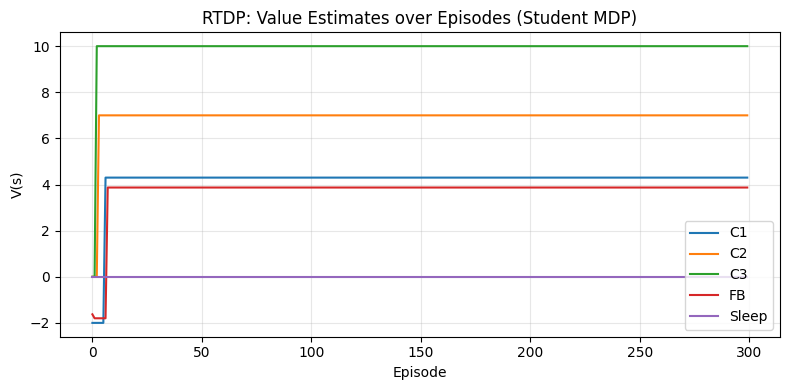

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Real-Time Dynamic Programming on the Student MDP ──
# Simulate agent episodes; only backup the state the agent is currently in.


def rtdp(S, terminal_states_mdp, gamma=0.9, n_episodes=200, max_steps=100, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    V = {s: 0.0 for s in S}
    non_terminal = [s for s in S if s not in terminal_states_mdp]

    value_snapshots = []  # V snapshot after each episode

    for ep in range(n_episodes):
        # Start in a random non-terminal state
        s = rng.choice(non_terminal)

        for _ in range(max_steps):
            if s in terminal_states_mdp:
                break

            # Bellman optimality backup for current state
            best_q = float("-inf")
            best_a = None
            for a in actions(s):
                q_sa = sum(
                    p * (reward_sa(s, a) + gamma * V[s_next])
                    for p, s_next in transitions_sa(s, a)
                )
                if q_sa > best_q:
                    best_q, best_a = q_sa, a
            V[s] = best_q

            # Follow greedy action and sample next state
            trans = transitions_sa(s, best_a)
            probs = [p for p, _ in trans]
            nexts = [sn for _, sn in trans]
            s = rng.choice(nexts, p=probs)

        value_snapshots.append({s: V[s] for s in S})

    # Extract greedy policy from final V
    policy = {}
    for s in S:
        if s in terminal_states_mdp:
            continue
        best_a, best_q = None, float("-inf")
        for a in actions(s):
            q_sa = sum(
                p * (reward_sa(s, a) + gamma * V[s_next])
                for p, s_next in transitions_sa(s, a)
            )
            if q_sa > best_q:
                best_q, best_a = q_sa, a
        policy[s] = best_a

    return V, policy, value_snapshots


V_rt, pi_rt, snapshots = rtdp(S, terminal_states_mdp, gamma=gamma, n_episodes=300)

print("Real-Time DP")
print(f"After {len(snapshots)} episodes\n")
for s in S:
    act = "TERMINAL" if s in terminal_states_mdp else pi_rt[s]
    print(f"  {s:>5}:  V = {V_rt[s]: .6f}   π = {act}")

# Plot value convergence per state across episodes
fig, ax = plt.subplots(figsize=(8, 4))
for s in S:
    vals = [snap[s] for snap in snapshots]
    ax.plot(vals, label=s)
ax.set_xlabel("Episode")
ax.set_ylabel("V(s)")
ax.set_title("RTDP: Value Estimates over Episodes (Student MDP)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Full-Width Backups

- DP uses *full-width* backups
- For each backup (sync or async)
  - Every successor state and action is considered
  - Using knowledge of the MDP transitions and reward function
- DP is effective for medium-sized problems (millions of states)
- For large problems DP suffers Bellman's *curse of dimensionality*
  - Number of states $n = |\mathcal{S}|$ grows exponentially with number of state variables
- Even one backup can be too expensive

> **Full-width:** Every single successor state $s'$ and every action $a$ is considered during each backup — nothing is approximated or sampled. This requires a complete model of the MDP (transitions $\mathcal{P}_{ss'}^a$ and rewards $\mathcal{R}_s^a$).
>
> **Why it works for medium problems:** If the state space fits in memory and one sweep is tractable, DP gives exact solutions with convergence guarantees.
>
> **Curse of dimensionality:** States are often described by multiple variables (e.g. position, velocity, inventory level…). If each variable has $k$ values and there are $d$ variables, then $|\mathcal{S}| = k^d$ — the state space explodes exponentially. DP becomes infeasible.
>
> **Consequence:** For large-scale problems, we need *sample-based* methods (e.g. Monte Carlo, TD learning) that avoid enumerating all successors and don't require a full model.

### Sample Backups

- In subsequent lectures we will consider *sample backups*
- Using sample rewards and sample transitions $\langle S, A, R, S' \rangle$
- Instead of reward function $\mathcal{R}$ and transition dynamics $\mathcal{P}$
- Advantages:
  - Model-free: no advance knowledge of MDP required
  - Breaks the curse of dimensionality through sampling
  - Cost of backup is constant, independent of $n = |\mathcal{S}|$

> **Sample backup vs full-width:** Instead of summing over *all* successor states weighted by their transition probabilities, just sample one transition $(S, A, R, S')$ and use that single experience to update the value estimate.
>
> **Model-free:** No need to know $\mathcal{P}_{ss'}^a$ or $\mathcal{R}_s^a$ explicitly. The agent learns purely from interactions with the environment.
>
> **Curse of dimensionality broken:** Full-width backups cost $O(n)$ per state. Sample backups cost $O(1)$ — you process one sampled transition regardless of how large the state space is.
>
> **The trade-off:** Sample backups introduce variance (one sample is noisy), whereas full-width backups are exact. Methods like Monte Carlo and TD learning manage this noise through averaging over many samples.

## Jack's car Rental

Optimal Policy (cars moved overnight):
[[ 0  0 -1 -1 -2 -2 -3 -3 -3 -4 -4 -5 -5 -5 -5 -5 -5 -5 -5 -5 -5]
 [ 1  0  0 -1 -1 -2 -2 -2 -3 -3 -4 -4 -5 -5 -5 -5 -5 -5 -5 -5 -5]
 [ 1  1  0  0 -1 -1 -1 -2 -2 -3 -3 -4 -4 -5 -5 -5 -5 -5 -5 -5 -5]
 [ 2  1  1  0  0  0 -1 -1 -2 -2 -3 -3 -4 -4 -5 -5 -5 -5 -5 -5 -5]
 [ 2  2  1  1  1  0  0 -1 -1 -2 -2 -3 -3 -4 -4 -5 -5 -5 -5 -5 -5]
 [ 3  2  2  2  1  1  0  0 -1 -1 -2 -2 -3 -3 -4 -4 -5 -5 -5 -5 -5]
 [ 3  3  3  2  2  1  1  0  0 -1 -1 -2 -2 -3 -3 -4 -5 -5 -5 -5 -5]
 [ 4  4  3  3  2  2  1  1  0  0 -1 -1 -2 -2 -3 -4 -4 -4 -4 -5 -5]
 [ 5  4  4  3  3  2  2  1  1  0  0 -1 -1 -2 -3 -3 -3 -3 -4 -4 -5]
 [ 5  5  4  4  3  3  2  2  1  1  0  0 -1 -2 -2 -2 -2 -3 -3 -4 -4]
 [ 5  5  5  4  4  3  3  2  2  1  1  0 -1 -1 -1 -1 -2 -2 -3 -3 -4]
 [ 5  5  5  5  4  4  3  3  2  2  1  0  0  0  0 -1 -1 -2 -2 -3 -3]
 [ 5  5  5  5  5  4  4  3  3  2  1  1  1  1  0  0 -1 -1 -2 -2 -3]
 [ 5  5  5  5  5  5  4  4  3  2  2  2  2  1  1  0  0 -1 -1 -2 -2]
 [ 5  5  5  5  5  5  5  4  3  3  3  3

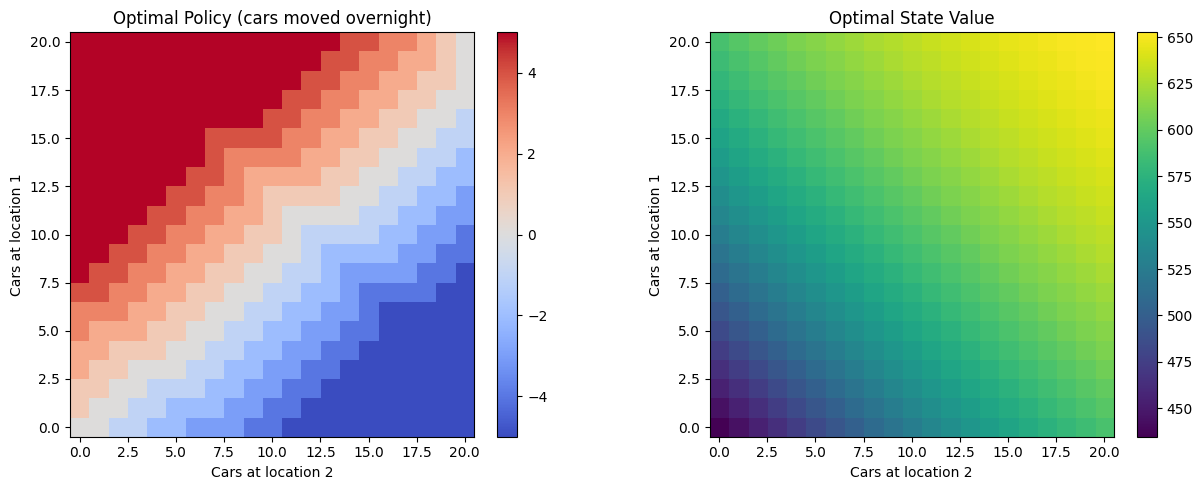

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Output current policy/value if they already exist in the notebook state
if "policy_jack" in globals() and "V_jack" in globals():
    print("Optimal Policy (cars moved overnight):")
    print(policy_jack)
    print("\nOptimal State Value:")
    print(V_jack)

# Jack's Car Rental (policy iteration)
max_cars = 20
max_move = 5
rent_reward = 10.0

# Poisson means
req1, ret1 = 3.0, 3.0
req2, ret2 = 4.0, 2.0

# Reuse notebook gamma/theta if already defined
gamma_jack = gamma if "gamma" in globals() else 0.9
theta_jack = 1e-3  # practical stopping threshold
poisson_upper = 11  # truncation for Poisson support


def poisson_pmf(n, lam):
    return math.exp(-lam) * (lam**n) / math.factorial(n)


def poisson_probs(lam, upper):
    probs = np.array([poisson_pmf(n, lam) for n in range(upper)], dtype=float)
    tail = max(0.0, 1.0 - probs.sum())
    probs = np.append(probs, tail)  # index=upper represents ">= upper"
    return probs


req_probs_1 = poisson_probs(req1, poisson_upper)
ret_probs_1 = poisson_probs(ret1, poisson_upper)
req_probs_2 = poisson_probs(req2, poisson_upper)
ret_probs_2 = poisson_probs(ret2, poisson_upper)


def build_location_model(req_probs, ret_probs):
    # For each starting cars c in [0..max_cars]:
    # - expected rentals E[min(req, c)]
    # - transition probs to next cars c'
    exp_rentals = np.zeros(max_cars + 1)
    trans = np.zeros((max_cars + 1, max_cars + 1))

    for c in range(max_cars + 1):
        for req_n, p_req in enumerate(req_probs):
            req_eff = min(req_n, poisson_upper)  # tail bucket at index=upper
            rented = min(c, req_eff)
            exp_rentals[c] += p_req * rented

            cars_after_rent = c - rented
            for ret_n, p_ret in enumerate(ret_probs):
                ret_eff = min(ret_n, poisson_upper)
                next_c = min(max_cars, cars_after_rent + ret_eff)
                trans[c, next_c] += p_req * p_ret

    # Numerical cleanup
    trans = trans / trans.sum(axis=1, keepdims=True)
    return exp_rentals, trans


exp_rent_1, trans_1 = build_location_model(req_probs_1, ret_probs_1)
exp_rent_2, trans_2 = build_location_model(req_probs_2, ret_probs_2)


def valid_actions(i, j):
    # action a > 0 means move a cars from loc1 -> loc2
    acts = []
    for a in range(-max_move, max_move + 1):
        if 0 <= i - a <= max_cars and 0 <= j + a <= max_cars:
            acts.append(a)
    return acts


def expected_return(i, j, a, V):
    i2, j2 = i - a, j + a
    reward = rent_reward * (exp_rent_1[i2] + exp_rent_2[j2])

    future = 0.0
    p_i = trans_1[i2]
    p_j = trans_2[j2]
    for ni in range(max_cars + 1):
        for nj in range(max_cars + 1):
            future += p_i[ni] * p_j[nj] * V[ni, nj]

    return reward + gamma_jack * future


def policy_iteration_jack(max_eval_iters=200):
    V = np.zeros((max_cars + 1, max_cars + 1), dtype=float)
    policy = np.zeros((max_cars + 1, max_cars + 1), dtype=int)  # start with "move 0"

    stable = False
    it = 0

    while not stable:
        it += 1

        # Policy Evaluation
        for _ in range(max_eval_iters):
            delta = 0.0
            V_new = V.copy()
            for i in range(max_cars + 1):
                for j in range(max_cars + 1):
                    a = int(policy[i, j])
                    V_new[i, j] = expected_return(i, j, a, V)
                    delta = max(delta, abs(V_new[i, j] - V[i, j]))
            V = V_new
            if delta < theta_jack:
                break

        # Policy Improvement
        stable = True
        for i in range(max_cars + 1):
            for j in range(max_cars + 1):
                old_a = int(policy[i, j])
                acts = valid_actions(i, j)
                q_vals = [expected_return(i, j, a, V) for a in acts]
                best_a = acts[int(np.argmax(q_vals))]
                policy[i, j] = best_a
                if best_a != old_a:
                    stable = False

        print(f"Policy iteration step {it} complete | stable={stable}")

    return V, policy, it


V_jack, policy_jack, n_pi_iters = policy_iteration_jack()
print(f"\nConverged in {n_pi_iters} policy-iteration step(s).")

# Visualize policy and value
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(policy_jack, origin="lower", cmap="coolwarm")
axes[0].set_title("Optimal Policy (cars moved overnight)")
axes[0].set_xlabel("Cars at location 2")
axes[0].set_ylabel("Cars at location 1")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(V_jack, origin="lower", cmap="viridis")
axes[1].set_title("Optimal State Value")
axes[1].set_xlabel("Cars at location 2")
axes[1].set_ylabel("Cars at location 1")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()